# Envelope detectors & gain-reduction reconstruction — Ableton ideal compressor

Sister notebook to `envelope_gr_comparison.ipynb`, run on the **Ableton
ideal-compressor** split of Diff-SSL-G-Comp (`ableton_compressed/`). This is a
*clean digital* compressor with a **single fixed setting**, so instead of
contrasting compressor settings we contrast **two songs**: a *dynamic* program
(gain reduction swings a lot) and a *dense* one (near-constant heavy reduction).

Same pipeline as before — reconstruct the wet as `dry * gain` from each
detector's estimated gain reduction, then look at and listen to the residual:

$$ \text{wet}(t) \approx \text{dry}(t)\cdot g(t), \qquad g(t)=10^{\,GR(t)/20}. $$

**Why this dataset is the interesting counterpart.** The Ableton compressor adds
essentially *no* nonlinearity — `wet` is `dry` times a smooth gain. So the
per-sample `wet/dry` (simple diff) inverts it almost perfectly (~190 dB SNR),
and the residual floor is set purely by how well a detector **tracks the gain**,
not by harmonics. Detector / window choice therefore matters much more here than
on the analog SSL G-Bus.

| Detector | Window | Character |
|---|---|---|
| Hilbert | none (instantaneous) | magnitude of the analytic signal |
| RMS, W = 64 / 256 / 1024 / 4096 | ~1.5 / 6 / 23 / 93 ms | symmetric (zero-phase) moving RMS |
| Simple diff | per-sample | raw instantaneous gain `wet/dry` |

In [89]:
import sys
from pathlib import Path

import numpy as np
from scipy.signal import hilbert
import matplotlib.pyplot as plt
from IPython.display import Audio, display

# eval_helpers (dry/wet pairing + segment reader for the Ableton split) lives in
# 03_initial_GR_pred -- same source the SOTA eval notebooks use.
REPO_ROOT = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (p / "pyproject.toml").is_file()),
    Path.cwd().resolve(),
)
sys.path.insert(0, str(REPO_ROOT / "03_initial_GR_pred"))

from eval_helpers import same_setting_pairs, _song_from_dry_path, _read_dry_wet_segment
from src.dsp import to_dB, to_amplitude

SR = 44100
EPS = 1e-10

DATA_ROOT = "/Volumes/Saola's Drive/AllCode/thesis/data/Diff-SSL-G-Comp"
SETTING   = "ableton_compressed"          # the single Ableton setting

# --- analysis: the same single cut as envelope_gr_comparison.ipynb -----------
SEG_DUR = 1.0      # seconds
PAD_S   = 0.25     # pre/post-roll trimmed after detection (edge dips / warm-up)

# (label -> (song, segment_start_s)). Both examples use the SSL notebook's exact
# cut, so the figures show the identical passage through the Ableton compressor.
EXAMPLES = {
    "dynamic": ("AncoraQui", 119.36),   # shared cut (same as the SSL notebook)
    "dense":   ("AncoraQui", 119.36),   # identical passage
}

RMS_WINDOWS = (64, 256, 1024, 4096)

# song -> (dry_path, wet_path) for the single Ableton setting
PAIRS = {_song_from_dry_path(d): (d, w)
         for d, w in same_setting_pairs(DATA_ROOT, SETTING)}
print(f"{len(PAIRS)} dry/wet pairs in '{SETTING}'")
for lbl, (song, st) in EXAMPLES.items():
    assert song in PAIRS, f"{song} not found in {SETTING}"
    print(f"  {lbl:8s} -> {song} @ {st}-{st + SEG_DUR}s")

60 dry/wet pairs in 'ableton_compressed'
  dynamic  -> AncoraQui @ 119.36-120.36s
  dense    -> AncoraQui @ 119.36-120.36s


## 1. Envelope detectors

Hilbert and RMS are **symmetric** (zero-phase): RMS uses `mode="same"`, so the
smoothing leaks equally before and after an event and cannot react fast to an
onset while recovering slowly. The window length trades transient tracking
(short) for smoothness (long).

In [90]:
def env_hilbert(x):
    '''Instantaneous envelope: magnitude of the analytic signal (no window).'''
    return np.abs(hilbert(x))


def env_rms(x, W):
    '''Symmetric (zero-phase) moving RMS over a window of W samples.'''
    p = np.convolve(x ** 2, np.ones(W) / W, mode="same")
    return np.sqrt(np.maximum(p, 0.0))

## 2. GR estimation & reconstruction pipeline

Order is **envelope → dB → GR → gain → reconstruction**: the dB conversion
happens right after each envelope and before the GR difference.

```
env_dry, env_wet            # linear envelopes
env_dry_dB, env_wet_dB      # dB conversion (right after the envelope)
GR_dB = env_wet_dB - env_dry_dB
gain  = 10 ** (GR_dB / 20)
recon = dry * gain
res   = wet - recon
```

The **simple diff** (per-sample `wet/dry`) is the reference; on this clean
digital compressor it reconstructs the target to ~machine precision.


In [91]:
def db_rms(x):
    '''RMS level of a signal in dBFS.'''
    return 20.0 * np.log10(np.sqrt(np.mean(x ** 2)) + 1e-12)


def compute_methods(dry, wet, windows=RMS_WINDOWS):
    '''Return {label: dict(env_dry, env_wet, gr_db, recon, residual, snr)}.'''
    results = {}

    detectors = [("Hilbert", env_hilbert(dry), env_hilbert(wet))]
    for W in windows:
        detectors.append((f"RMS {W}", env_rms(dry, W), env_rms(wet, W)))

    for label, env_dry, env_wet in detectors:
        env_dry_db = to_dB(env_dry)          # dB right after the envelope ...
        env_wet_db = to_dB(env_wet)
        gr_db = env_wet_db - env_dry_db      # ... so GR is a dB difference
        recon = dry * to_amplitude(gr_db)
        res = wet - recon
        results[label] = dict(env_dry=env_dry, env_wet=env_wet, gr_db=gr_db,
                              recon=recon, residual=res, snr=db_rms(wet) - db_rms(res))

    # simple per-sample diff: gain = wet/dry computed sample by sample
    gain = np.divide(wet, dry, out=np.ones_like(wet), where=np.abs(dry) > EPS)
    recon = dry * gain
    res = wet - recon
    results["Simple diff"] = dict(env_dry=None, env_wet=None,
                                  gr_db=to_dB(np.abs(gain)), recon=recon,
                                  residual=res, snr=db_rms(wet) - db_rms(res))
    return results


def crop(results, sl):
    '''Slice every array field of every method by `sl` (drops pad / warm-up).'''
    out = {}
    for label, d in results.items():
        out[label] = {k: (v[sl] if isinstance(v, np.ndarray) else v)
                      for k, v in d.items()}
    return out

## 3. Load the two example segments

Each example loads its own (dry, wet) pair for the Ableton setting, with a small
pad that is cropped after detection so edge effects never reach the plotted /
audible region.

In [92]:
pad_n = int(PAD_S * SR)
N     = int(SEG_DUR * SR)
sl    = slice(pad_n, pad_n + N)

DATA = {}
for label, (song, start_s) in EXAMPLES.items():
    dry_path, wet_path = PAIRS[song]
    a = int((start_s - PAD_S) * SR)
    b = int((start_s + SEG_DUR + PAD_S) * SR)
    dry_t, wet_t = _read_dry_wet_segment(dry_path, wet_path, a, b, SR)
    d_pad = dry_t.squeeze(0).numpy().astype(np.float64)
    w_pad = wet_t.squeeze(0).numpy().astype(np.float64)
    n = min(len(d_pad), len(w_pad))
    d_pad, w_pad = d_pad[:n], w_pad[:n]

    res_full = compute_methods(d_pad, w_pad)
    DATA[label] = dict(
        song=song, dry=d_pad[sl], wet=w_pad[sl], results=crop(res_full, sl),
        t=np.arange(N) / SR + start_s,
    )
    print(f"{label:8s}  {song} @ {start_s}s   target={db_rms(w_pad[sl]):.1f} dBFS")
    for lbl, dd in DATA[label]["results"].items():
        print(f"          {lbl:12s} residual {db_rms(dd['residual']):8.1f} dBFS   "
              f"SNR {dd['snr']:6.1f} dB")

dynamic   AncoraQui @ 119.36s   target=-44.8 dBFS
          Hilbert      residual    -93.8 dBFS   SNR   48.7 dB
          RMS 64       residual    -87.9 dBFS   SNR   44.2 dB
          RMS 256      residual    -71.8 dBFS   SNR   28.4 dB
          RMS 1024     residual    -64.2 dBFS   SNR   20.9 dB
          RMS 4096     residual    -59.0 dBFS   SNR   15.4 dB
          Simple diff  residual   -240.0 dBFS   SNR  195.0 dB
dense     AncoraQui @ 119.36s   target=-44.8 dBFS
          Hilbert      residual    -93.8 dBFS   SNR   48.7 dB
          RMS 64       residual    -87.9 dBFS   SNR   44.2 dB
          RMS 256      residual    -71.8 dBFS   SNR   28.4 dB
          RMS 1024     residual    -64.2 dBFS   SNR   20.9 dB
          RMS 4096     residual    -59.0 dBFS   SNR   15.4 dB
          Simple diff  residual   -240.0 dBFS   SNR  195.0 dB


## 4. Plot helper (3 stacked panels)

1. **input + envelopes** — the dry waveform with each detector's envelope.
2. **gain reduction curves** — the estimated `GR(t)` (dB) for each method.
3. **residuals** — `target − reconstruction` (legend shows residual SNR).

Audio players for each figure's residuals are placed **directly below it** (the
sample-by-sample *Simple diff* is skipped). Pass `zoom=(start_s, dur_s)` to zoom
in on a transient (the analysis stays 6 s).


In [93]:
COLORS = {
    "Simple diff": "0.45", "Hilbert": "tab:blue", "RMS 64": "tab:green",
    "RMS 256": "tab:olive", "RMS 1024": "tab:orange", "RMS 4096": "tab:red",
}

# Detector "speed": Hilbert is instantaneous (fastest), RMS slows with its
# window. Used only for layering -- panels 1 & 2 draw fast detectors behind slow
# ones (signal / Simple diff at the very back), the residual panel flips it so
# the fastest (Hilbert) sits in front. Legend order stays the method-list order.
SPEED_RANK = {"Hilbert": 0, "RMS 64": 1, "RMS 256": 2, "RMS 1024": 3, "RMS 4096": 4}


def _minmax(t, x, n_bins=2500):
    '''Peak-preserving decimation for waveform display. Keeps the trailing
    samples that don't fill a whole bin so the line spans the full time axis.'''
    n = len(x)
    if n <= 2 * n_bins:
        return t, x
    step = n // n_bins
    m = step * n_bins
    xb = x[:m].reshape(n_bins, step)
    tt = np.repeat(t[:m].reshape(n_bins, step)[:, 0], 2)
    xx = np.empty(n_bins * 2)
    xx[0::2], xx[1::2] = xb.min(1), xb.max(1)
    if m < n:                                    # absorb the leftover tail samples
        tail = x[m:]
        tt = np.concatenate([tt, [t[m], t[-1]]])
        xx = np.concatenate([xx, [tail.min(), tail.max()]])
    return tt, xx


def plot_three(key, methods, env_methods, title, zoom=None):
    '''Panels: input+envelopes / gain-reduction curves / residuals.
    zoom=(start_s, dur_s) restricts the x-axis (analysis itself stays 6 s).'''
    D = DATA[key]
    t, dry, wet, R = D["t"], D["dry"], D["wet"], D["results"]
    fig, ax = plt.subplots(3, 1, sharex=True, figsize=(13, 10), tight_layout=True)

    # --- panel 1: input + envelopes (back -> front: signal, fast ... slow) ---
    tt, xx = _minmax(t, dry)
    ax[0].plot(tt, xx, color="0.85", lw=0.4, zorder=0, label="Input (dry)")
    for lbl in env_methods:
        env = R[lbl]["env_dry"]
        ax[0].plot(t[::16], env[::16], color=COLORS[lbl], lw=1.3,
                   zorder=1 + SPEED_RANK[lbl], label=f"{lbl} env")
    ax[0].set_title(f"{title}\nInput + detector envelopes")
    ax[0].set_ylabel("amplitude")
    ax[0].legend(ncol=4, fontsize=8, loc="upper right")
    ax[0].grid(alpha=0.3)

    # --- panel 2: gain reduction curves (layered like panel 1) --------------
    for lbl in methods:
        gr = R[lbl]["gr_db"]
        z = 0 if lbl == "Simple diff" else 1 + SPEED_RANK[lbl]
        ax[1].plot(t[::16], gr[::16], color=COLORS[lbl], lw=1.0, zorder=z,
                   alpha=0.30 if lbl == "Simple diff" else 0.95, label=lbl)
    ax[1].axhline(0, color="k", lw=0.6, ls="--", alpha=0.5)
    smooth = [l for l in methods if l != "Simple diff"]
    if smooth:
        allgr = np.concatenate([R[l]["gr_db"] for l in smooth])
        lo, hi = np.percentile(allgr, 1), np.percentile(allgr, 99)
        m = 0.15 * (hi - lo + 1e-9)
        ax[1].set_ylim(lo - m, hi + m)
    ax[1].set_title("Gain reduction curves")
    ax[1].set_ylabel("gain reduction [dB]")
    ax[1].legend(ncol=5, fontsize=8, loc="lower right")
    ax[1].grid(alpha=0.3)

    # --- panel 3: residuals (back -> front: slow ... fast, Hilbert in front) -
    for lbl in methods:
        tt, xx = _minmax(t, R[lbl]["residual"])
        z = 0 if lbl == "Simple diff" else 10 - SPEED_RANK[lbl]
        ax[2].plot(tt, xx, color=COLORS[lbl], lw=0.5, zorder=z,
                   label=f"{lbl}  (SNR {R[lbl]['snr']:.1f} dB)")
    ax[2].set_title("Residual = target - reconstruction")
    ax[2].set_ylabel("amplitude")
    ax[2].set_xlabel("time [s]")
    ax[2].legend(ncol=5, fontsize=8, loc="upper right")
    ax[2].grid(alpha=0.3)
    # x-axis pinned to the signal extent (sharex -> applies to all panels) so
    # there is no empty margin; zoom overrides it with the requested window.
    if zoom is not None:
        ax[0].set_xlim(zoom[0], zoom[0] + zoom[1])
    else:
        ax[0].set_xlim(t[0], t[-1])
    plt.show()


def play_residuals(key, methods, label=""):
    '''Audio for a figure's residuals (skips the sample-by-sample Simple diff).
    Common make-up gain per example so relative loudness is faithful.'''
    D = DATA[key]
    g = 0.9 / (np.max(np.abs(D["wet"])) + 1e-9)
    print(f"{key.upper()}  {label}  -  target + residuals  (make-up gain x{g:.1f})")
    items = [("Target (wet)", D["wet"])]
    for lbl in methods:
        if lbl == "Simple diff":
            continue
        items.append((f"Residual - {lbl}", D["results"][lbl]["residual"]))
    for lbl, x in items:
        print(lbl)
        display(Audio(np.clip(x * g, -1, 1), rate=SR, normalize=False))

## 5. Version A — detector approaches (one RMS vs the rest)

Hilbert and RMS-1024, plus the per-sample *simple diff*. Unlike the analog SSL,
here the residual SNR (panel 3) **spreads widely**: the simple diff and the fast
detectors invert the clean digital gain almost perfectly, while the slow
detectors smear it and leave audible pumping. Detector choice is the story.

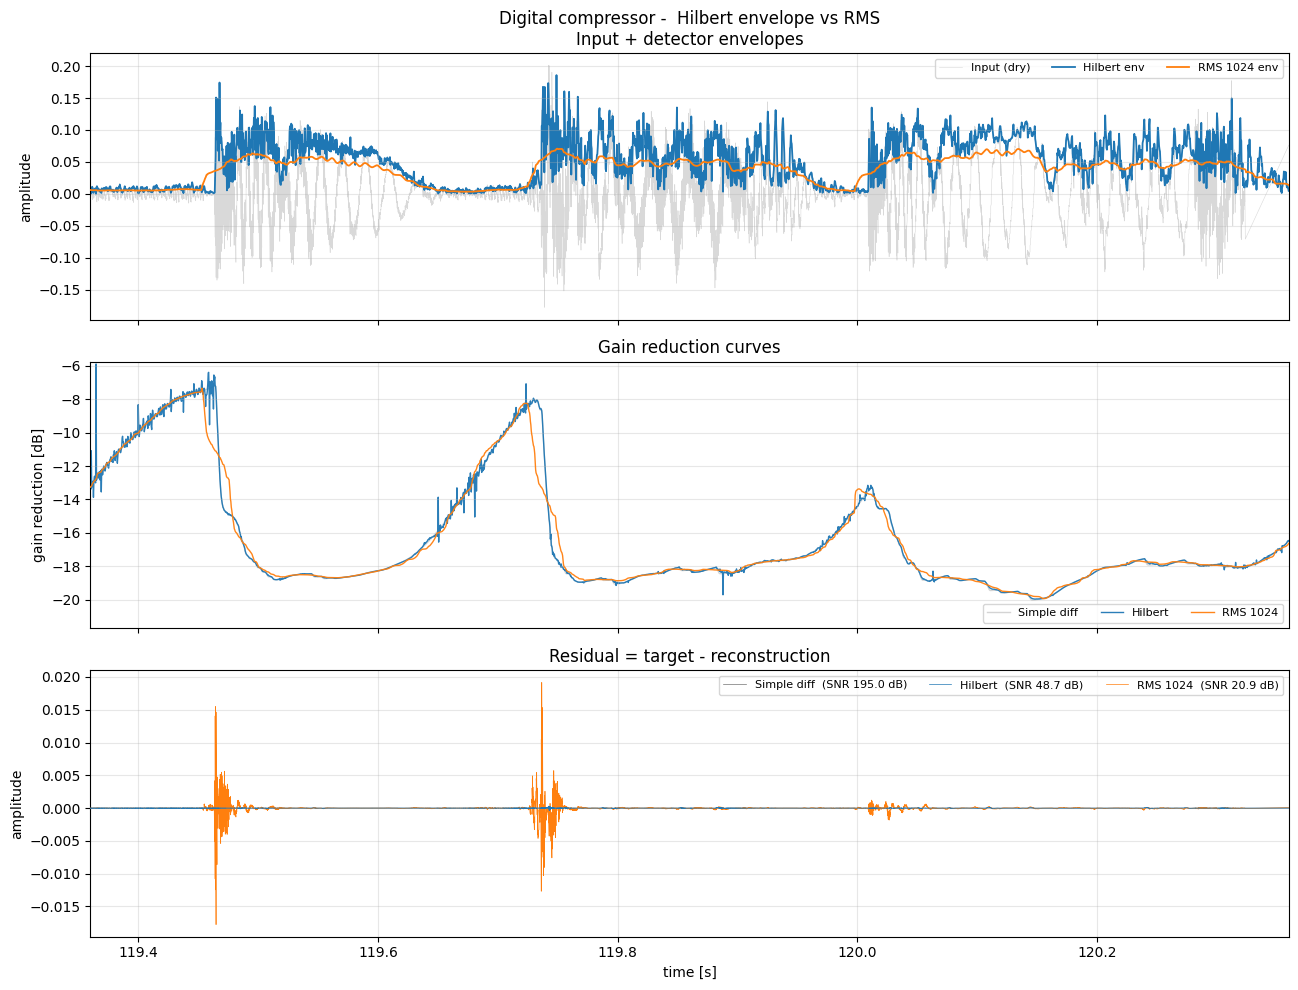

In [94]:
APPROACH_METHODS = ["Simple diff", "Hilbert", "RMS 1024"]
APPROACH_ENVS    = ["Hilbert", "RMS 1024"]

plot_three("dynamic", APPROACH_METHODS, APPROACH_ENVS,
           f"Digital compressor -  Hilbert envelope vs RMS")

In [95]:
play_residuals("dynamic", APPROACH_METHODS, "approaches")

DYNAMIC  approaches  -  target + residuals  (make-up gain x16.6)
Target (wet)


Residual - Hilbert


Residual - RMS 1024


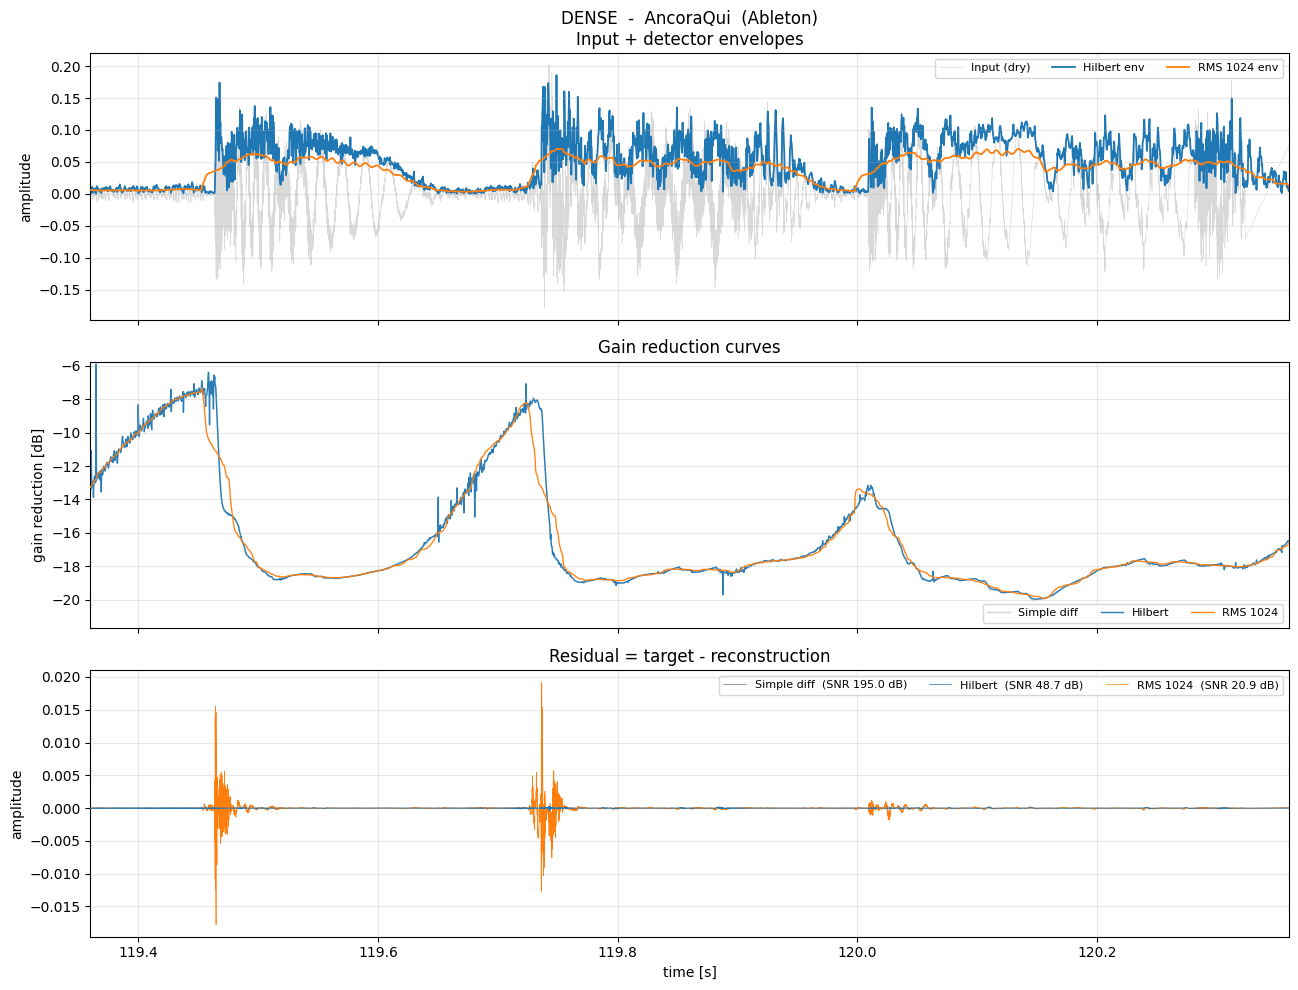

In [96]:
plot_three("dense", APPROACH_METHODS, APPROACH_ENVS,
           f"DENSE  -  {EXAMPLES['dense'][0]}  (Ableton)")

In [97]:
play_residuals("dense", APPROACH_METHODS, "approaches")

DENSE  approaches  -  target + residuals  (make-up gain x16.6)
Target (wet)


Residual - Hilbert


Residual - RMS 1024


## 6. Version B — RMS window-size comparison

RMS at **W = 4096 / 1024 / 256 / 64** (drawn largest → smallest). On this clean
compressor the short window wins decisively (it tracks the fast gain changes),
and the gap to the long windows is much larger than on the analog device.

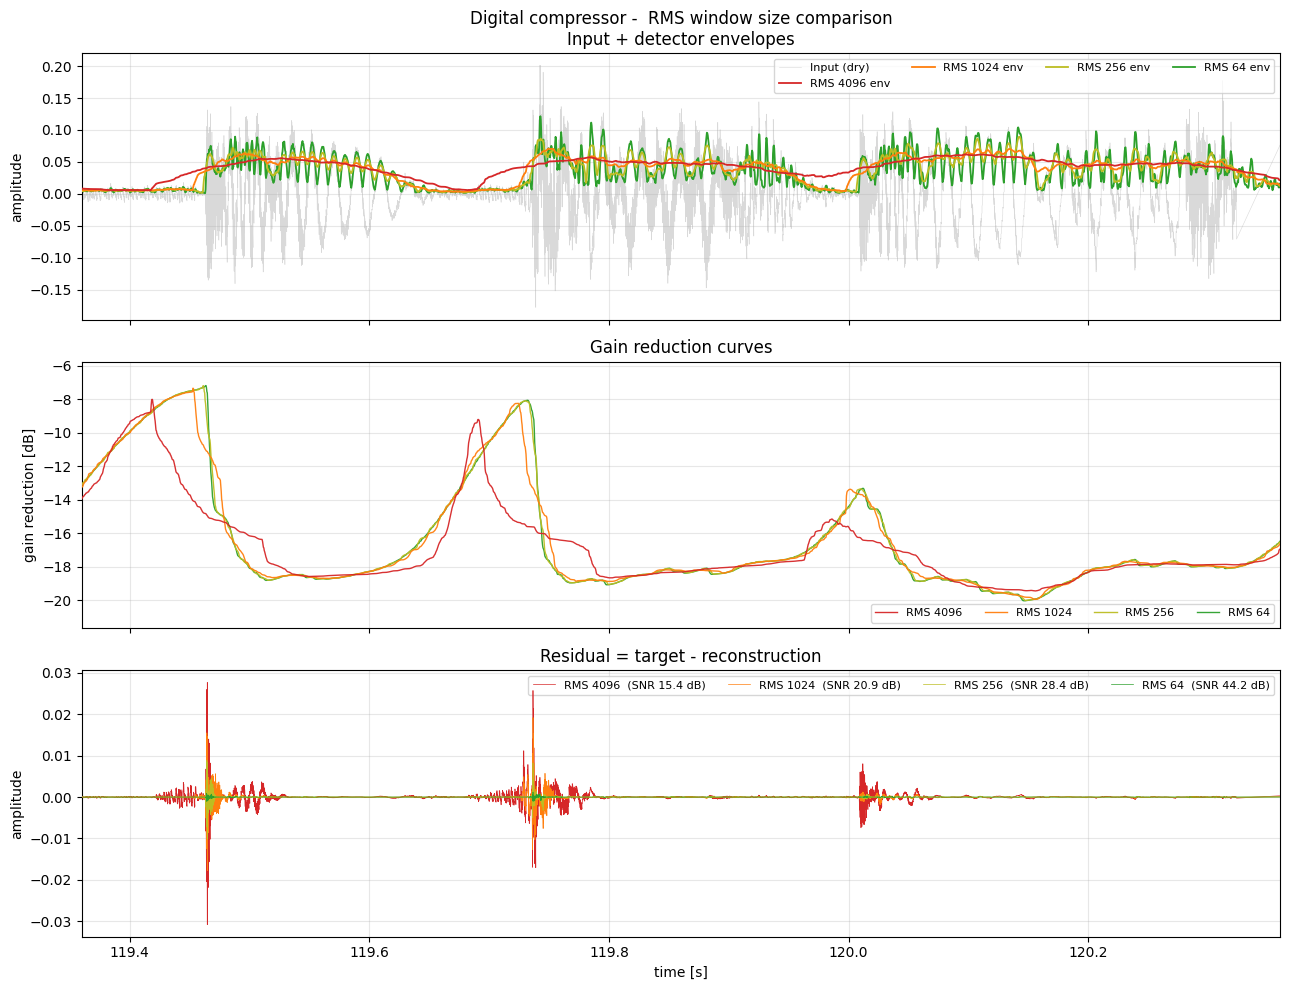

In [98]:
WINDOW_METHODS = [f"RMS {W}" for W in sorted(RMS_WINDOWS, reverse=True)]

plot_three("dynamic", WINDOW_METHODS, WINDOW_METHODS,
           f"Digital compressor -  RMS window size comparison")

In [99]:
play_residuals("dynamic", WINDOW_METHODS, "windows")

DYNAMIC  windows  -  target + residuals  (make-up gain x16.6)
Target (wet)


Residual - RMS 4096


Residual - RMS 1024


Residual - RMS 256


Residual - RMS 64


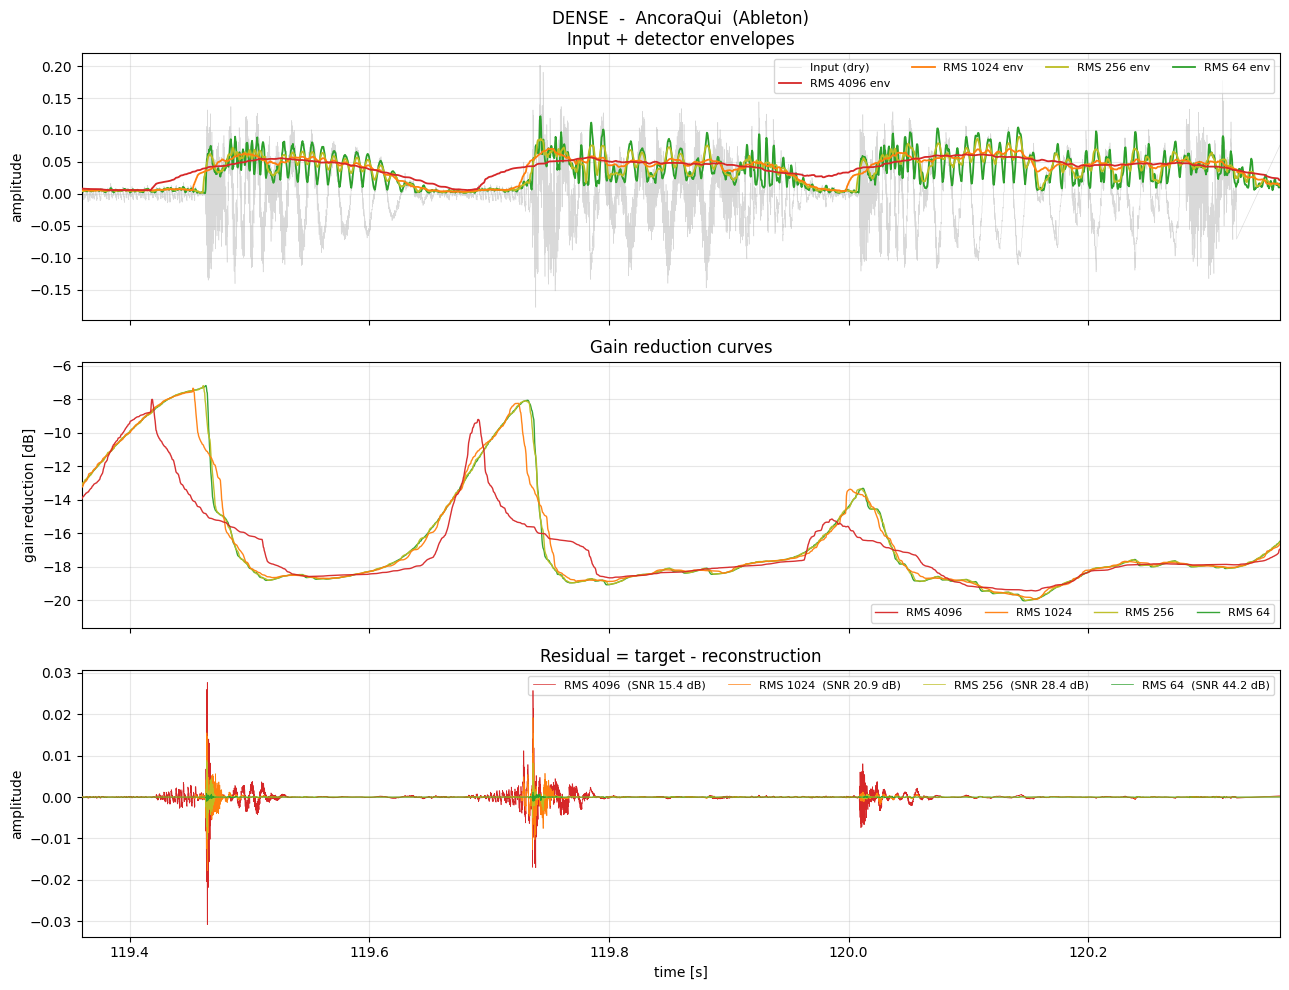

In [100]:
plot_three("dense", WINDOW_METHODS, WINDOW_METHODS,
           f"DENSE  -  {EXAMPLES['dense'][0]}  (Ableton)")

In [101]:
play_residuals("dense", WINDOW_METHODS, "windows")

DENSE  windows  -  target + residuals  (make-up gain x16.6)
Target (wet)


Residual - RMS 4096


Residual - RMS 1024


Residual - RMS 256


Residual - RMS 64


### Zoom — waveform-level detail

~0.4 s on the *dynamic* example, where you can see where the residual energy
sits for each detector.

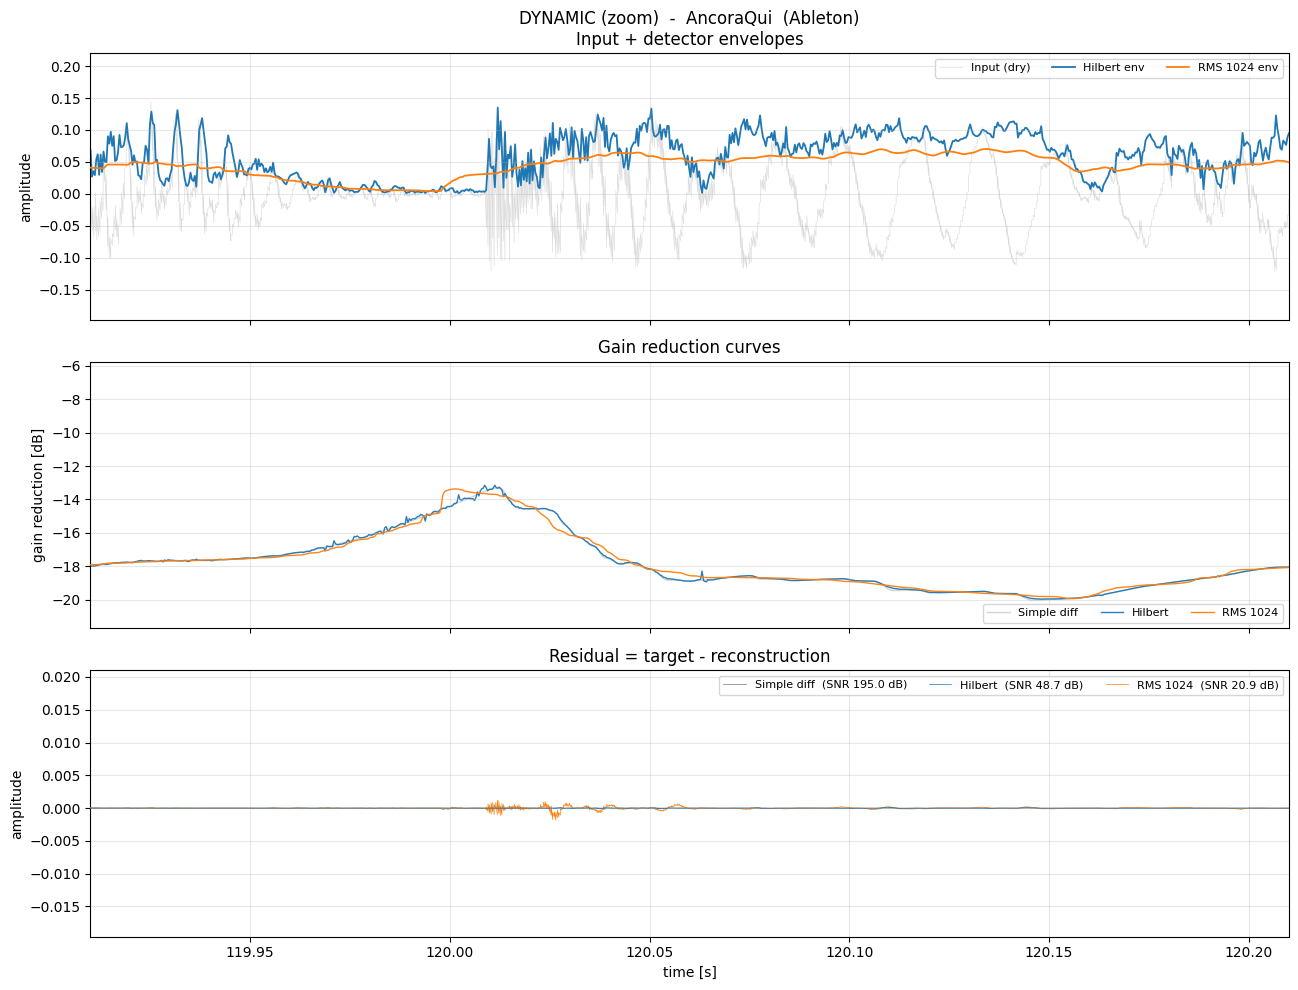

In [102]:
plot_three("dynamic", APPROACH_METHODS, APPROACH_ENVS,
           f"DYNAMIC (zoom)  -  {EXAMPLES['dynamic'][0]}  (Ableton)",
           zoom=(EXAMPLES["dynamic"][1] + 0.55, 0.3))